## Veille technologique

Contexte

Comparaison d'une architecture CNN classique et d'un modèle Transformer pour la classification d'images
## Contexte

Les réseaux de neurones convolutifs (CNN) ont longtemps été les architectures dominantes en vision par ordinateur.
Cependant, l'apparition des Vision Transformers (ViT) a introduit une nouvelle approche basée sur les mécanismes d'attention issus du domaine du NLP.

L'objectif de ce projet est de comparer :

- une architecture CNN classique : ResNet50
- une architecture Transformer : Vision Transformer (ViT)

sur une tâche de classification d'images issue d'un dataset e-commerce Flipkart.

In [5]:
#importation des libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix)
import tensorflow as tf
from google.colab import drive

# ResNet
from tensorflow.keras.applications import ResNet50

# PyTorch / ViT
import torch
from transformers import (
    ViTImageProcessor,
    ViTForImageClassification)

from PIL import Image
import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [6]:
#importation google colab
from google.colab import files
uploaded = files.upload()

Saving flipkart_com-ecommerce_sample_1050.csv to flipkart_com-ecommerce_sample_1050.csv


In [7]:
#création df"
df = pd.read_csv("flipkart_com-ecommerce_sample_1050.csv")

Le dataset utilisé est un échantillon e-commerce Flipkart contenant environ 1050 images réparties dans plusieurs catégories.

In [8]:
df

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,958f54f4c46b53c8a0a9b8167d9140bc,2015-12-01 10:15:43 +0000,http://www.flipkart.com/oren-empower-extra-lar...,Oren Empower Extra Large Self Adhesive Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE88ZGTX65GH4V,1399.0,999.0,958f54f4c46b53c8a0a9b8167d9140bc.jpg,False,Oren Empower Extra Large Self Adhesive Sticker...,No rating available,No rating available,Oren Empower,"{""product_specification""=>[{""key""=>""Number of ..."
1046,fd6cbcc22efb6b761bd564c28928483c,2015-12-01 10:15:43 +0000,http://www.flipkart.com/wallmantra-large-vinyl...,Wallmantra Large Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIEC889ZD5GDCVQ,4930.0,1896.0,fd6cbcc22efb6b761bd564c28928483c.jpg,False,Wallmantra Large Vinyl Sticker Sticker (Pack o...,No rating available,No rating available,Wallmantra,"{""product_specification""=>[{""key""=>""Number of ..."
1047,5912e037d12774bb73a2048f35a00009,2015-12-01 10:15:43 +0000,http://www.flipkart.com/uberlyfe-extra-large-p...,Uberlyfe Extra Large Pigmented Polyvinyl Films...,"[""Baby Care >> Baby & Kids Gifts >> Stickers >...",STIE5UVGW2JWVWCT,4500.0,1449.0,5912e037d12774bb73a2048f35a00009.jpg,False,Buy Uberlyfe Extra Large Pigmented Polyvinyl F...,No rating available,No rating available,Uberlyfe,"{""product_specification""=>[{""key""=>""Number of ..."
1048,c3edc504d1b4f0ba6224fa53a43a7ad6,2015-12-01 10:15:43 +0000,http://www.flipkart.com/wallmantra-medium-viny...,Wallmantra Medium Vinyl Sticker Sticker,"[""Baby Care >> Baby & Kids Gifts >> Stickers >.

In [9]:
df=df.copy()

# Préprocessing

Les étapes de préparation doivent rester identiques pour les deux modèles afin d'assurer une comparaison équitable.

Les étapes réalisées :

- Extraction des catégories
- Suppression des variables inutiles
- Préparation des labels
- Préparation des images

In [10]:
#Preprocessing
def clean_categories(df):
  "Extraction de la catégorie"
  df["product_category"]= (df["product_category_tree"].str.split(" >> ").str[0])

  df["product_catefory"]=(df)["product_category"]=(df["product_category"].str.replace(r'[\[\]\"]', '', regex=True).str.strip())

  return df

In [11]:
def remove_columns(df):
  "Suprression des variables non utilisés pour le modéle"
  columns_to_drop=[
      "crawl_timestamp",
        "product_url",
        "product_name",
        "pid",
        "retail_price",
        "discounted_price",
        "image",
        "is_FK_Advantage_product",
        "description",
        "product_rating",
        "overall_rating",
        "brand",
        "product_specifications",
        "product_category_tree"
  ]

  return df.drop(columns=columns_to_drop,
        errors="ignore")

In [12]:
data=clean_categories(df)
data_clean=remove_columns(data)

In [8]:
data_clean.head()

,uniq_id,product_category,product_catefory
0,55b85ea15a1536d46b7190ad6fff8ce7,Home Furnishing,Home Furnishing
1,7b72c92c2f6c40268628ec5f14c6d590,Baby Care,Baby Care
2,64d5d4a258243731dc7bbb1eef49ad74,Baby Care,Baby Care
3,d4684dcdc759dd9cdf41504698d737d8,Home Furnishing,Home Furnishing
4,6325b6870c54cd47be6ebfbffa620ec7,Home Furnishing,Home Furnishing


In [13]:
data_clean["product_category"].value_counts()

,count
product_category,
Home Furnishing,150
Baby Care,150
Watches,150
Home Decor & Festive Needs,150
Kitchen & Dining,150
Beauty and Personal Care,150
Computers,150


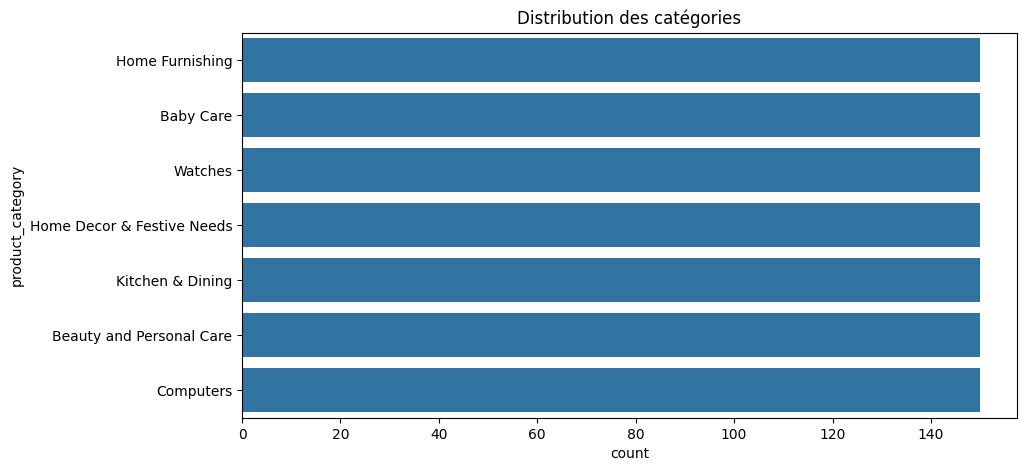

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(
    data=data_clean,
    y="product_category")
plt.title(
    "Distribution des catégories")
plt.show()

In [15]:
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
img_dir = "/content/drive/MyDrive/Images"

In [17]:
files = os.listdir(img_dir)
len(files), files[:10]

(1050,
 ['0e73201f6d8807776e1d21c969078289.jpg',
  '0ddc40c08d9a9bafc4d14eddd98db7c0.jpg',
  '10b6738d7058738a9a7d107bbb2833f4.jpg',
  '0e1e3861d54a8a17b7b91f04071a4ca3.jpg',
  '0dc4d2767fe8424a3263ab141884f83d.jpg',
  '0d02f4703fde00645704e15bba23e77d.jpg',
  '0ec47240feda42c63e42f1e9cee60f7a.jpg',
  '0c4718ae90f2889b7021a99ee1cc106c.jpg',
  '0d3e1dc0d38be59e9927e47f152e48aa.jpg',
  '0ca8e323551dd7107ef57ef7c3e77aee.jpg'])

In [18]:
data_clean["image_path"] = (img_dir + "/" + data_clean["uniq_id"] + ".jpg")

In [19]:
data_clean

,uniq_id,product_category,product_catefory,image_path
0,55b85ea15a1536d46b7190ad6fff8ce7,Home Furnishing,Home Furnishing,/content/drive/MyDrive/Images/55b85ea15a1536d4...
1,7b72c92c2f6c40268628ec5f14c6d590,Baby Care,Baby Care,/content/drive/MyDrive/Images/7b72c92c2f6c4026...
2,64d5d4a258243731dc7bbb1eef49ad74,Baby Care,Baby Care,/content/drive/MyDrive/Images/64d5d4a258243731...
3,d4684dcdc759dd9cdf41504698d737d8,Home Furnishing,Home Furnishing,/content/drive/MyDrive/Images/d4684dcdc759dd9c...
4,6325b6870c54cd47be6ebfbffa620ec7,Home Furnishing,Home Furnishing,/content/drive/MyDrive/Images/6325b6870c54cd47...
...,...,...,...,...
1045,958f54f4c46b53c8a0a9b8167d9140bc,Baby Care,Baby Care,/content/drive/MyDrive/Images/958f54f4c46b53c8...
1046,fd6cbcc22efb6b761bd564c28928483c,Baby Care,Baby Care,/content/drive/MyDrive/Images/fd6cbcc22efb6b76...
1047,5912e037d12774bb73a2048f35a00009,Baby Care,Baby Care,/content/drive/MyDrive/Images/5912e037d12774bb...
1048,c3edc504d1b4f0ba6224fa53a43a7ad6,Baby Care,Baby Care,/content/drive/MyDrive/Images/c3edc504d1b4f0ba...


In [20]:
data_path = data_clean.copy()

#fonctions

In [21]:
def montrer_images(df, category, n):
    "Fonction qui affiche n images d'une categorie selectionné"
    images = df[df["product_category"] == category]["image_path"].head(n)
    for image_path in images:
        img = Image.open(image_path)
        plt.imshow(img)
        plt.title(category)
        plt.axis("off")
        plt.show()

In [22]:
def chargement_image(path):
  img=Image.open(path)
  img=img.convert("RGB")
  img=img.resize((224,224))
  return np.array(img)

In [23]:
def afficher_matrice_confusion(y_true, y_pred, classes, titre):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.title(titre)

    plt.show()

Encodage des categories

In [24]:
encoder = LabelEncoder()
data_clean["label"] = encoder.fit_transform(
    data_clean["product_category"]
)

Séparation Train / Test

In [25]:
train_df, test_df = train_test_split(data_clean,test_size=0.2,random_state=42,stratify=data_clean["label"])
#utilisation de stratify pour garder les même proportions

In [26]:
def creation_dataset(df):

    X = []
    y = []

    for index, row in df.iterrows():

        X.append(chargement_image(row["image_path"]))
        y.append(row["label"])

    return np.array(X), np.array(y)

In [27]:
X_train, y_train = creation_dataset(train_df)

X_test, y_test = creation_dataset(test_df)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


In [28]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(840, 224, 224, 3)
(840,)
(210, 224, 224, 3)
(210,)


In [29]:
nb_classes = data_clean["label"].nunique()

In [30]:
nb_classes

7

In [31]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [32]:
base_model.trainable = False

In [33]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

output = Dense(
    7,
    activation="softmax"
)(x)

In [34]:
model_resnet = Model(
    inputs=base_model.input,
    outputs=output
)

In [35]:
model_resnet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,602,055 (90.03 MB)

 Trainable params: 14,343 (56.03 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [36]:
model_resnet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [38]:
history_resnet = model_resnet.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 38s 888ms/step - accuracy: 0.4357 - loss: 1.6990 - val_accuracy: 0.6905 - val_loss: 0.9583
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.7667 - loss: 0.7522 - val_accuracy: 0.7238 - val_loss: 0.7948
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.8202 - loss: 0.5653 - val_accuracy: 0.7571 - val_loss: 0.7901
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.8429 - loss: 0.4822 - val_accuracy: 0.7952 - val_loss: 0.7504
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.8714 - loss: 0.4045 - val_accuracy: 0.7857 - val_loss: 0.7022
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.9012 - loss: 0.3338 - val_accuracy: 0.8143 - val_loss: 0.7034
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.8869 - loss: 0.3295 - val_accuracy: 0.7905 - val_loss: 0.6950
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.9238 - loss: 0.2623 - val_accuracy: 

In [39]:
y_prob_resnet = model_resnet.predict(X_test)

y_pred_resnet = np.argmax(y_prob_resnet, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 956ms/step


In [40]:
print(
    classification_report(
        y_test,
        y_pred_resnet,
        target_names=encoder.classes_
    )
)

                            precision    recall  f1-score   support

                 Baby Care       0.78      0.60      0.68        30
  Beauty and Personal Care       0.95      0.70      0.81        30
                 Computers       0.71      0.80      0.75        30
Home Decor & Festive Needs       0.75      0.80      0.77        30
           Home Furnishing       0.75      0.90      0.82        30
          Kitchen & Dining       0.82      0.93      0.88        30
                   Watches       0.93      0.90      0.92        30

                  accuracy                           0.80       210
                 macro avg       0.81      0.80      0.80       210
              weighted avg       0.81      0.80      0.80       210



In [41]:
def afficher_matrice_confusion(y_true, y_pred, classes, titre):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.title(titre)

    plt.show()

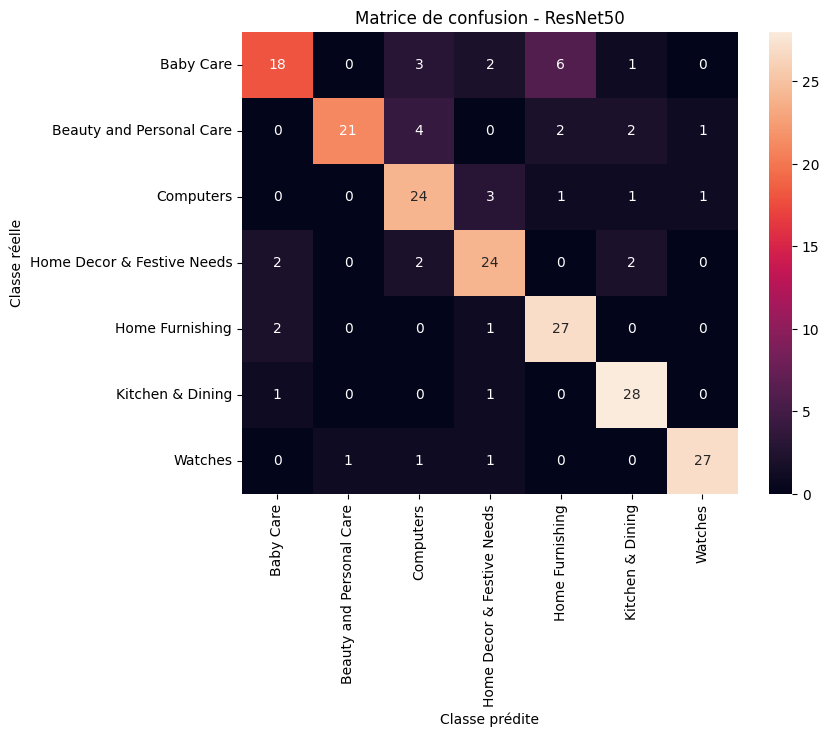

In [42]:
afficher_matrice_confusion(y_test,y_pred_resnet,encoder.classes_,
    "Matrice de confusion - ResNet50")

Vit

In [44]:
from transformers import ViTImageProcessor, ViTModel

In [45]:
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [46]:
def preparation_vit(X):

    images = []

    for img in X:
        img = Image.fromarray(img.astype("uint8"))
        images.append(img)

    return images

In [47]:
images_train = preparation_vit(X_train)

images_test = preparation_vit(X_test)

In [48]:
inputs_train = processor(
    images_train,
    return_tensors="pt")

inputs_test = processor(
    images_test,
    return_tensors="pt")

In [49]:
inputs_test["pixel_values"].shape

torch.Size([210, 3, 224, 224])

In [50]:
vit_model.eval()

with torch.no_grad():

    outputs_train = vit_model(
        **inputs_train)

    outputs_test = vit_model(
        **inputs_test)

In [51]:
features_train = outputs_train.last_hidden_state[:,0,:]

features_test = outputs_test.last_hidden_state[:,0,:]

In [52]:
features_train.shape

torch.Size([840, 768])

In [54]:
from sklearn.linear_model import LogisticRegression

In [55]:
classifier_vit = LogisticRegression(
    max_iter=1000)

classifier_vit.fit(
    features_train,
    y_train)

LogisticRegression(max_iter=1000)

In [56]:
y_pred_vit = classifier_vit.predict(
    features_test)

In [57]:
print(
    classification_report(
        y_test,
        y_pred_vit,
        target_names=encoder.classes_
    )
)

                            precision    recall  f1-score   support

                 Baby Care       0.83      0.80      0.81        30
  Beauty and Personal Care       0.88      0.93      0.90        30
                 Computers       0.97      0.97      0.97        30
Home Decor & Festive Needs       0.86      0.80      0.83        30
           Home Furnishing       0.88      0.93      0.90        30
          Kitchen & Dining       0.94      1.00      0.97        30
                   Watches       1.00      0.90      0.95        30

                  accuracy                           0.90       210
                 macro avg       0.91      0.90      0.90       210
              weighted avg       0.91      0.90      0.90       210



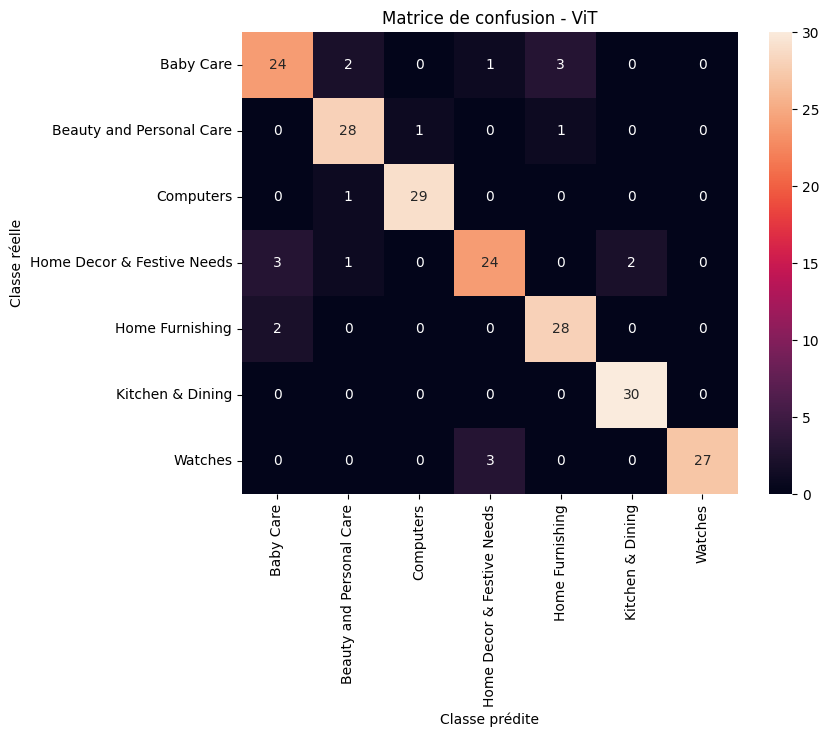

In [58]:
afficher_matrice_confusion(
    y_test,
    y_pred_vit,
    encoder.classes_,
    "Matrice de confusion - ViT")